<a href="https://colab.research.google.com/github/DivyaMeenaSundaram/Probability-and-Statistics/blob/main/2.%20Bernoulli_Binomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A cloud-storage service monitors file downloads. Each download either succeeds or fails. The operations team wants to estimate the failure rate and use probability to understand future download behaviour.

In [1]:
# Import the file-upload tool provided by Google Colab
from google.colab import files

# Open a window to upload the Excel file
uploaded = files.upload()

Saving download_failure_dataset.xlsx to download_failure_dataset (1).xlsx


In [3]:
import pandas as pd

# Read the uploaded Excel file
data = pd.read_excel("download_failure_dataset.xlsx")

# Display the complete dataset
data

,Download_ID,File_Size_MB,Network_Type,File_Type,Status
0,1,10,WiFi,Video,Success
1,2,25,5G,PDF,Success
2,3,300,WiFi,Document,Success
3,4,5,WiFi,Image,Success
4,5,500,WiFi,Document,Success
...,...,...,...,...,...
95,96,150,5G,Image,Success
96,97,50,WiFi,Image,Success
97,98,5,WiFi,Video,Success
98,99,150,5G,Image,Success


In [5]:
# Count how many downloads were successful and how many failed

status_counts = data["Status"].value_counts()

print(status_counts)

Status
Success    95
Failure     5
Name: count, dtype: int64


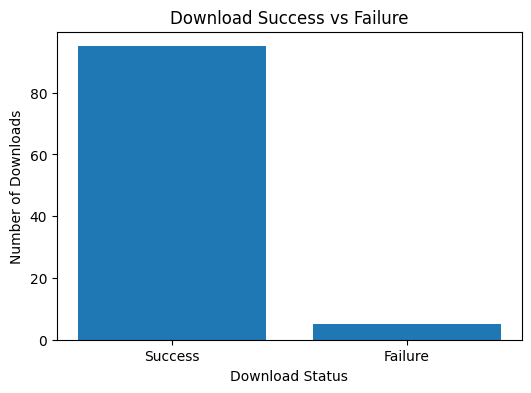

In [6]:
import matplotlib.pyplot as plt

# Count the number of successful and failed downloads
status_counts = data["Status"].value_counts()

# Create a bar chart
plt.figure(figsize=(6, 4))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.xlabel("Download Status")
plt.ylabel("Number of Downloads")
plt.title("Download Success vs Failure")

plt.show()

What percentage of download attempts failed?

In [7]:
# Count the number of failed downloads

failed_downloads = (data["Status"] == "Failure").sum()

print("Number of failed downloads:", failed_downloads)

Number of failed downloads: 5


In [8]:
# Count the total number of download attempts

total_downloads = len(data)

print("Total downloads:", total_downloads)

Total downloads: 100


In [9]:
# Calculate the download failure rate

failure_rate = failed_downloads / total_downloads

print("Failure rate:", failure_rate)

Failure rate: 0.05


In [10]:
# Convert the failure rate into a percentage

failure_percentage = failure_rate * 100

print(f"Download failure rate: {failure_percentage:.2f}%")

Download failure rate: 5.00%


We know the estimated failure probability for one download, which is 5%. What if we monitor the next 100 downloads? How many failures will occur among 100 downloads?

In [11]:
from scipy.stats import binom

# Number of future download attempts
n = 100

# Estimated probability that one download fails
p = failure_rate

# Probability of exactly 5 failures
probability_5_failures = binom.pmf(
    5,      # Number of failures we are interested in
    n,      # Total number of downloads
    p       # Probability of failure
)

print(
    f"Probability of exactly 5 failures: "
    f"{probability_5_failures:.4f}"
)

print(
    f"Percentage: "
    f"{probability_5_failures * 100:.2f}%"
)

Probability of exactly 5 failures: 0.1800
Percentage: 18.00%


In [12]:
# Probability of 5 or fewer failures
probability_at_most_5 = binom.cdf(
    5,
    n,
    p
)

print(
    f"Probability of 5 or fewer failures: "
    f"{probability_at_most_5 * 100:.2f}%"
)

Probability of 5 or fewer failures: 61.60%


pmf → exactly

cdf → up to / at most

In [13]:
#Exactly 5 failures
binom.pmf(5, 100, 0.05)

np.float64(0.18001782727042887)

In [14]:
# 0, 1, 2, 3, 4, or 5 failures.
binom.cdf(5, 100, 0.05)

np.float64(0.6159991279561414)

Suppose the operations team wants to investigate whenever more than 10 downloads fail in a batch of 100. How likely is that?

In [15]:
# Probability of more than 10 failures
#
# We calculate this as:
# 1 - probability of 10 or fewer failures

probability_more_than_10 = 1 - binom.cdf(
    10,
    n,
    p
)

print(
    f"Probability of more than 10 failures: "
    f"{probability_more_than_10 * 100:.2f}%"
)

Probability of more than 10 failures: 1.15%
